# Практическое задание №4  
Выполнил: Мамаев А.

## Вариант 4: Датасет «Diamonds» (характеристики алмазов)  
• Источник: sns.load_dataset('diamonds')   
• Описание: Цена и характеристики алмазов (карат, огранка, цвет, прозрачность).   
• Задачи: 
1. Проверить наличие пропусков. 
2. Удалить дубликаты, если есть. 
3. Создать признак volume = x*y*z (если есть такие столбцы; в датасете есть x, 
y, z – габариты). 
4. Отфильтровать алмазы с ценой выше 10000 и каратами больше 1. 
5. Построить зависимость цены от карата для разных типов огранки. 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [3]:
# Загружаем заданный по варианту датасет
df = sns.load_dataset('diamonds') 
print("Размер исходных данных:", df.shape) 
df.head()

Размер исходных данных: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Вывод общей информации по датасету
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


Изучив информацию выше, мы видим, что в датасете нет пропусков.  
Далее произведем проверку на наличие дубликатов и их удаление при наличии в датасете

In [7]:
duplicates = df.duplicated()
print("Количество дупликатов: ", duplicates.sum())

Количество дупликатов:  146


В датесете есть 146 дупликатов, избавимся от них

In [8]:
df.drop_duplicates(inplace=True)
duplicates = df.duplicated()
print("Количество дупликатов после очистки: ", duplicates.sum())

Количество дупликатов после очистки:  0


In [9]:
# Создадим признак volume
df['volume'] = df['x'] * df['y'] * df['z']
df

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,115.920000
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,118.110175
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,114.449728
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,140.766120


Отфильтруем алмазы с ценой выше 10000 и каратами больше 1

In [10]:
filtered_df = df[(df['price'] > 10000) & (df['carat'] > 1)]
filtered_df

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
21928,1.70,Ideal,J,VS2,60.5,58.0,10002,7.73,7.74,4.68,280.005336
21929,1.03,Ideal,E,VVS2,60.6,59.0,10003,6.50,6.53,3.95,167.657750
21930,1.23,Very Good,G,VVS2,60.6,55.0,10004,6.93,7.02,4.23,205.783578
21931,1.25,Ideal,F,VS2,61.6,55.0,10006,6.93,6.96,4.28,206.436384
21932,2.01,Very Good,I,SI2,61.4,63.0,10009,8.19,7.96,4.96,323.354304
...,...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01,318.636000
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11,340.663260
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56,249.029352
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04,317.333520


In [11]:
filtered_df.to_csv('filtered_diamonds.csv', index=False)

In [15]:
print("Предобработка завершена. Размер итогового датасета:", filtered_df.shape)

Предобработка завершена. Размер итогового датасета: (5186, 11)


В заключении построим график зависимости цены от карата для разных типов огранки

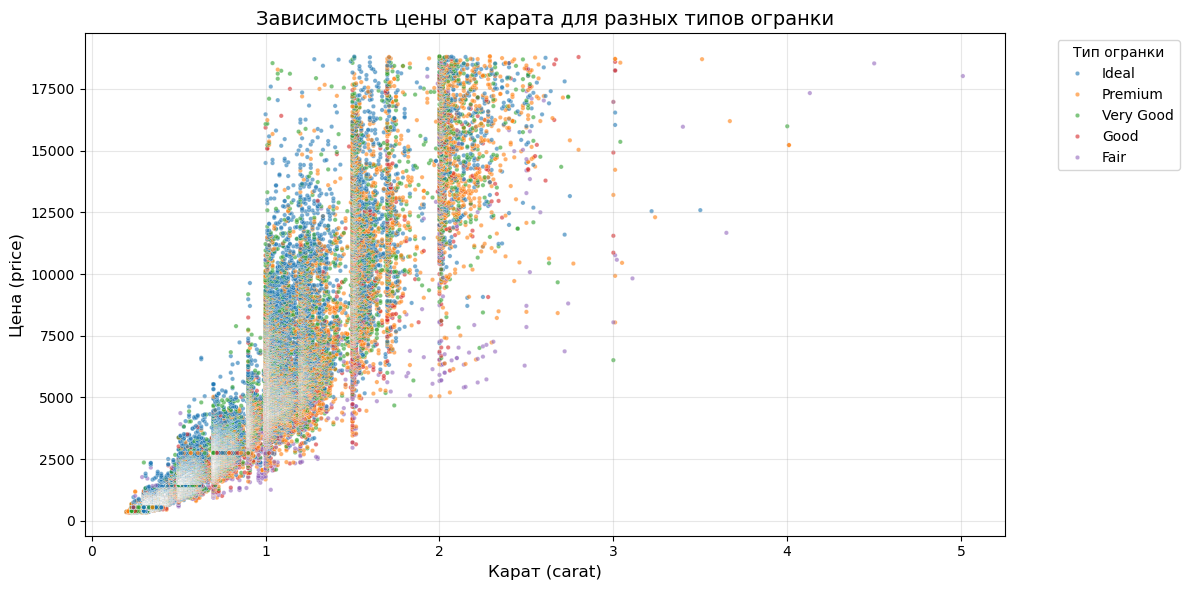

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='carat', y='price', hue='cut', alpha=0.6, s=10)

plt.title('Зависимость цены от карата для разных типов огранки', fontsize=14)
plt.xlabel('Карат (carat)', fontsize=12)
plt.ylabel('Цена (price)', fontsize=12)
plt.legend(title='Тип огранки', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()